## Debug

PROCESS FIRST FILE ONLY
Date: 20200101
VIIRS: ../../Mozambique_S/result/caresst_whole_l3s_2020/geotiff/20200101.tif
REAL L3S 256x256 GEOINFO
L3S: ../../L3S_STAR/raw/2020-01/PM/20200101120000-STAR-L3S_GHRSST-SSTsubskin-LEO_PM_N-ACSPO_V2.81-v02.0-fv01.0.nc
lon: 37.16999816894531 42.27000045776367
lat: -19.209999084472656 -14.109999656677246
transform:
| 0.02, 0.00, 37.17|
| 0.00,-0.02,-14.11|
| 0.00, 0.00, 1.00|
INPUT VIIRS 300x300
Path: ../../Mozambique_S/result/caresst_whole_l3s_2020/geotiff/20200101.tif
Shape: (300, 300)
CRS: EPSG:4326
Bounds: BoundingBox(left=-0.07068561949458808, bottom=-19.242122828761072, right=42.34068607725826, top=0.032123744288415815)
Transform:
| 0.14, 0.00,-0.07|
| 0.00,-0.06, 0.03|
| 0.00, 0.00, 1.00|
[INFO] Applied flip up-down to VIIRS 256.


/tmp/ipykernel_493237/3940191992.py:164: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1).astype(np.float32)
/tmp/ipykernel_493237/3940191992.py:187: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  src_mask = src.read(1).astype(np.float32)


REPROJECTED LAND MASK TO L3S 256 GRID
land pixels: 3312
ocean pixels: 62224
TILTED VIIRS FOOTPRINT
finite VIIRS pixels: 6358
footprint pixels: 6577
land pixels excluded: 3312
IDW CHECK — LIMITED TO TILTED VIIRS FOOTPRINT
valid pixels: 6281
fill target pixels: 296


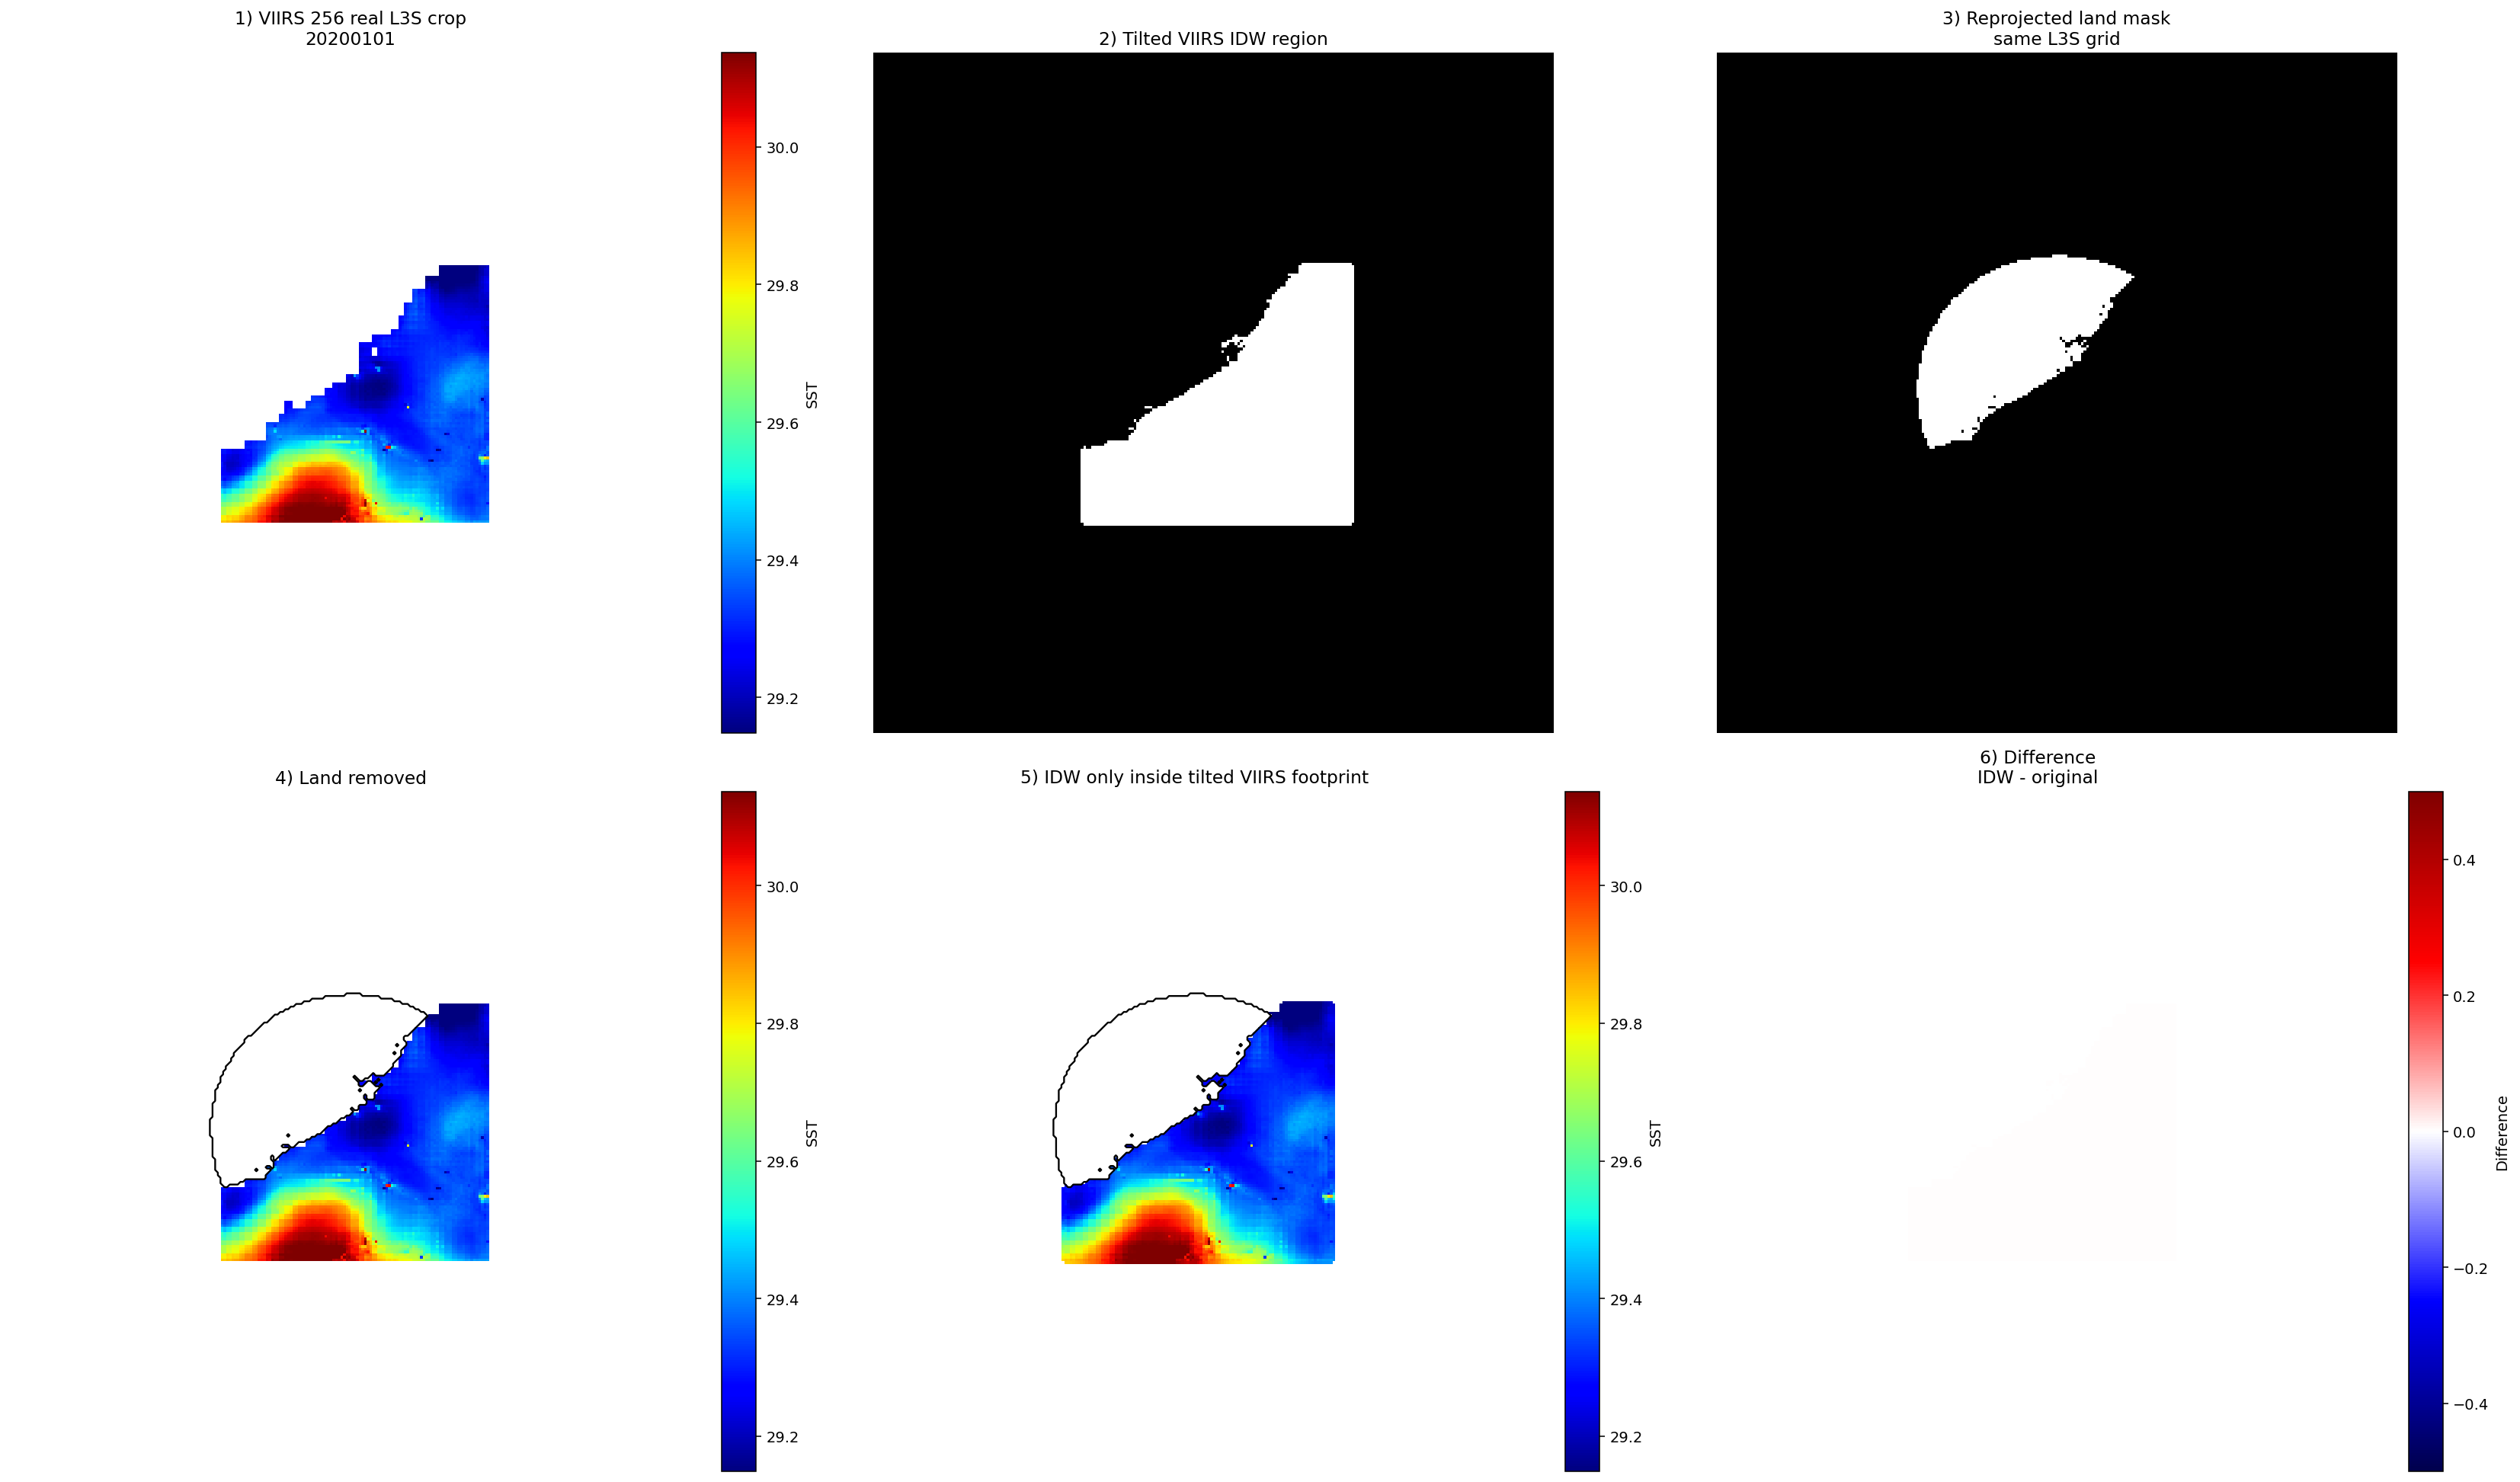

DONE
First file only.
No files were saved.


In [4]:
# =========================================================
# DEBUG FROM BATCH CODE — FIRST FILE ONLY
# Keep final 300x300 for CARE-SST
# Run IDW only inside real tilted 256x256 L3S/VIIRS footprint
# Plot same as debug version
# Save nothing
# =========================================================

from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling
from scipy.spatial import cKDTree
from scipy.ndimage import binary_fill_holes, binary_dilation
import xarray as xr

# =========================================================
# CONFIG
# =========================================================
SITE = "Mozambique_S"
YEAR = "2020"

CENTER_LON = 39.730014649575104
CENTER_LAT = -16.644973730979025

TARGET_SIZE = 300
CROP_SIZE = 256
HALF_SIZE = CROP_SIZE // 2

PAD = (TARGET_SIZE - CROP_SIZE) // 2
R0, R1 = PAD, PAD + CROP_SIZE
C0, C1 = PAD, PAD + CROP_SIZE

VIIRS_PRODUCT = "_PM_N-"

ROOT = Path(f"../../{SITE}/result")
VIIRS_TIF_DIR = ROOT / f"caresst_whole_l3s_{YEAR}" / "geotiff"

MASK_TIF = Path(f"../../{SITE}/land_mask/landmask.tif")
L3_ROOT = Path("../../L3S_STAR/raw")

IDW_K = 8
IDW_POWER = 2
IDW_MAX_DISTANCE = None

FLIP_UP_DOWN = True
FOOTPRINT_DILATE_ITER = 1

CMAP = "jet"
PLOT_ORIGIN = "upper"


# =========================================================
# HELPERS
# =========================================================
def extract_ymd(path):
    m = re.search(r"(20\d{6})", path.stem)
    return m.group(1) if m else path.stem


def find_l3_path(date_str):
    yyyy = date_str[:4]
    mm = date_str[4:6]

    pm_dir = L3_ROOT / f"{yyyy}-{mm}" / "PM"

    if not pm_dir.exists():
        raise FileNotFoundError(f"Missing L3S folder: {pm_dir}")

    cands = sorted(pm_dir.glob(f"{date_str}*STAR-L3S*.nc"))

    if not cands:
        raise FileNotFoundError(f"No L3S file found for {date_str}")

    preferred = [f for f in cands if VIIRS_PRODUCT in f.name]

    if preferred:
        return preferred[0]

    print(f"[WARN] No file matched {VIIRS_PRODUCT}; using first available")
    return cands[0]


def get_l3s_crop_lonlat_transform(l3_path):
    ds = xr.open_dataset(l3_path, decode_timedelta=False)
    ds = ds.sortby("lat").sortby("lon")

    sst = ds["sea_surface_temperature"].squeeze()

    lat_idx = np.abs(sst.lat.values - CENTER_LAT).argmin()
    lon_idx = np.abs(sst.lon.values - CENTER_LON).argmin()

    start_lat_idx = lat_idx - HALF_SIZE
    end_lat_idx = lat_idx + HALF_SIZE
    start_lon_idx = lon_idx - HALF_SIZE
    end_lon_idx = lon_idx + HALF_SIZE

    if (
        start_lat_idx < 0
        or end_lat_idx > sst.sizes["lat"]
        or start_lon_idx < 0
        or end_lon_idx > sst.sizes["lon"]
    ):
        raise ValueError("Crop outside L3S grid.")

    crop = sst.isel(
        lat=slice(start_lat_idx, end_lat_idx),
        lon=slice(start_lon_idx, end_lon_idx),
    )

    lats = crop.lat.values.astype(np.float64)
    lons = crop.lon.values.astype(np.float64)
    lons = np.where(lons > 180, lons - 360, lons)

    lon_grid, lat_grid = np.meshgrid(lons, lats)

    lon_min = float(np.nanmin(lon_grid))
    lon_max = float(np.nanmax(lon_grid))
    lat_min = float(np.nanmin(lat_grid))
    lat_max = float(np.nanmax(lat_grid))

    transform = from_bounds(
        lon_min,
        lat_min,
        lon_max,
        lat_max,
        CROP_SIZE,
        CROP_SIZE,
    )

    print("=" * 80)
    print("REAL L3S 256x256 GEOINFO")
    print("=" * 80)
    print("L3S:", l3_path)
    print("lon:", lon_min, lon_max)
    print("lat:", lat_min, lat_max)
    print("transform:")
    print(transform)

    return lon_grid, lat_grid, transform, "EPSG:4326"


def clean_sst(arr, nodata=None):
    out = arr.copy().astype(np.float32)

    if nodata is not None:
        out[out == nodata] = np.nan

    out[out <= -9999] = np.nan

    if np.nanmedian(out) > 100:
        out = out - 273.15

    out[(out <= 0) | (out > 45)] = np.nan

    return out


def read_viirs_300(tif_path):
    with rasterio.open(tif_path) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata

        print("=" * 80)
        print("INPUT VIIRS 300x300")
        print("=" * 80)
        print("Path:", tif_path)
        print("Shape:", arr.shape)
        print("CRS:", src.crs)
        print("Bounds:", src.bounds)
        print("Transform:")
        print(src.transform)

    arr = clean_sst(arr, nodata=nodata)

    if arr.shape != (TARGET_SIZE, TARGET_SIZE):
        raise ValueError(f"Expected 300x300 input, got {arr.shape}")

    return arr


def reproject_landmask_to_l3s_grid(mask_tif, dst_transform, dst_crs):
    with rasterio.open(mask_tif) as src:
        src_mask = src.read(1).astype(np.float32)
        src_transform = src.transform
        src_crs = src.crs
        src_nodata = src.nodata

    if src_nodata is not None:
        src_mask[src_mask == src_nodata] = 0

    src_land = (src_mask == 1).astype(np.uint8)

    dst_land = np.zeros((CROP_SIZE, CROP_SIZE), dtype=np.uint8)

    reproject(
        source=src_land,
        destination=dst_land,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,
        src_nodata=0,
        dst_nodata=0,
    )

    land_bool = dst_land == 1

    print("=" * 80)
    print("REPROJECTED LAND MASK TO L3S 256 GRID")
    print("=" * 80)
    print("land pixels:", int(np.sum(land_bool)))
    print("ocean pixels:", int(np.sum(~land_bool)))

    return land_bool


def make_viirs_footprint(viirs_256, land_256):
    finite = np.isfinite(viirs_256)

    footprint = binary_fill_holes(finite)

    if FOOTPRINT_DILATE_ITER > 0:
        footprint = binary_dilation(
            footprint,
            iterations=FOOTPRINT_DILATE_ITER,
        )

    footprint = footprint & (~land_256)

    print("=" * 80)
    print("TILTED VIIRS FOOTPRINT")
    print("=" * 80)
    print("finite VIIRS pixels:", int(np.sum(finite)))
    print("footprint pixels:", int(np.sum(footprint)))
    print("land pixels excluded:", int(np.sum(land_256)))

    return footprint


def idw_fill_2d_limited(arr, land_mask, idw_region, k=8, power=2, max_distance=None):
    out = arr.copy().astype(np.float32)

    out[land_mask] = np.nan

    valid = np.isfinite(out) & (~land_mask) & idw_region
    fill_target = (~np.isfinite(out)) & (~land_mask) & idw_region

    valid_rows, valid_cols = np.where(valid)
    fill_rows, fill_cols = np.where(fill_target)

    print("=" * 80)
    print("IDW CHECK — LIMITED TO TILTED VIIRS FOOTPRINT")
    print("=" * 80)
    print("valid pixels:", len(valid_rows))
    print("fill target pixels:", len(fill_rows))

    if len(valid_rows) == 0:
        raise ValueError("No valid pixels available for IDW fill.")

    if len(fill_rows) == 0:
        print("No missing pixels to fill.")
        return out

    valid_points = np.column_stack([valid_rows, valid_cols])
    fill_points = np.column_stack([fill_rows, fill_cols])
    valid_values = out[valid_rows, valid_cols]

    tree = cKDTree(valid_points)

    distances, indices = tree.query(
        fill_points,
        k=min(k, len(valid_points)),
    )

    if distances.ndim == 1:
        distances = distances[:, None]
        indices = indices[:, None]

    if max_distance is not None:
        too_far = distances[:, 0] > max_distance
    else:
        too_far = np.zeros(len(fill_points), dtype=bool)

    distances = np.maximum(distances, 1e-6)

    weights = 1.0 / (distances ** power)
    neighbor_values = valid_values[indices]

    filled_values = (
        np.sum(weights * neighbor_values, axis=1)
        / np.sum(weights, axis=1)
    )

    keep = ~too_far
    out[fill_rows[keep], fill_cols[keep]] = filled_values[keep]

    out[~idw_region] = arr[~idw_region]
    out[land_mask] = np.nan

    return out


# =========================================================
# MAIN — FIRST FILE ONLY, NO SAVE
# =========================================================
viirs_files = sorted(VIIRS_TIF_DIR.glob("*.tif"))

if len(viirs_files) == 0:
    raise FileNotFoundError(f"No tif files found in {VIIRS_TIF_DIR}")

viirs_path = viirs_files[0]
ymd = extract_ymd(viirs_path)

print("=" * 80)
print("PROCESS FIRST FILE ONLY")
print("=" * 80)
print("Date:", ymd)
print("VIIRS:", viirs_path)

l3_path = find_l3_path(ymd)

lon_grid, lat_grid, l3s_transform, l3s_crs = get_l3s_crop_lonlat_transform(l3_path)

viirs_300_raw = read_viirs_300(viirs_path)

viirs_256 = viirs_300_raw[R0:R1, C0:C1].copy()

if FLIP_UP_DOWN:
    viirs_256 = np.flipud(viirs_256)
    print("[INFO] Applied flip up-down to VIIRS 256.")

land_256 = reproject_landmask_to_l3s_grid(
    MASK_TIF,
    dst_transform=l3s_transform,
    dst_crs=l3s_crs,
)

idw_region_256 = make_viirs_footprint(
    viirs_256,
    land_256,
)

viirs_256_land_removed = viirs_256.copy()
viirs_256_land_removed[land_256] = np.nan

viirs_256_idw = idw_fill_2d_limited(
    arr=viirs_256_land_removed,
    land_mask=land_256,
    idw_region=idw_region_256,
    k=IDW_K,
    power=IDW_POWER,
    max_distance=IDW_MAX_DISTANCE,
)

viirs_300_idw = viirs_300_raw.copy()

if FLIP_UP_DOWN:
    paste_back_256 = np.flipud(viirs_256_idw)
else:
    paste_back_256 = viirs_256_idw

viirs_300_idw[R0:R1, C0:C1] = paste_back_256

vals = np.concatenate([
    viirs_256[np.isfinite(viirs_256)],
    viirs_256_idw[np.isfinite(viirs_256_idw)],
])

vmin = np.nanpercentile(vals, 2)
vmax = np.nanpercentile(vals, 98)

diff_256 = viirs_256_idw - viirs_256

fig, axes = plt.subplots(2, 3, figsize=(24, 14), dpi=140)

im0 = axes[0, 0].imshow(
    viirs_256,
    cmap=CMAP,
    vmin=vmin,
    vmax=vmax,
    origin=PLOT_ORIGIN,
)
axes[0, 0].set_title(f"1) VIIRS 256 real L3S crop\n{ymd}")
axes[0, 0].axis("off")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04, label="SST")

axes[0, 1].imshow(
    idw_region_256,
    cmap="gray",
    origin=PLOT_ORIGIN,
)
axes[0, 1].set_title("2) Tilted VIIRS IDW region")
axes[0, 1].axis("off")

axes[0, 2].imshow(
    land_256,
    cmap="gray",
    origin=PLOT_ORIGIN,
)
axes[0, 2].set_title("3) Reprojected land mask\nsame L3S grid")
axes[0, 2].axis("off")

im3 = axes[1, 0].imshow(
    viirs_256_land_removed,
    cmap=CMAP,
    vmin=vmin,
    vmax=vmax,
    origin=PLOT_ORIGIN,
)
axes[1, 0].contour(
    land_256.astype(float),
    levels=[0.5],
    colors="black",
    linewidths=1.2,
)
axes[1, 0].set_title("4) Land removed")
axes[1, 0].axis("off")
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04, label="SST")

im4 = axes[1, 1].imshow(
    viirs_256_idw,
    cmap=CMAP,
    vmin=vmin,
    vmax=vmax,
    origin=PLOT_ORIGIN,
)
axes[1, 1].contour(
    land_256.astype(float),
    levels=[0.5],
    colors="black",
    linewidths=1.2,
)
axes[1, 1].set_title("5) IDW only inside tilted VIIRS footprint")
axes[1, 1].axis("off")
plt.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04, label="SST")

im5 = axes[1, 2].imshow(
    diff_256,
    cmap="seismic",
    vmin=-0.5,
    vmax=0.5,
    origin=PLOT_ORIGIN,
)
axes[1, 2].set_title("6) Difference\nIDW - original")
axes[1, 2].axis("off")
plt.colorbar(im5, ax=axes[1, 2], fraction=0.046, pad=0.04, label="Difference")

plt.tight_layout()
plt.show()

print("=" * 80)
print("DONE")
print("First file only.")
print("No files were saved.")
print("=" * 80)

## Batch process

In [1]:
# =========================================================
# BATCH PROCESS
# Keep final 300x300 for CARE-SST
# Run IDW only inside real tilted 256x256 L3S/VIIRS footprint
# Save final 300x300 IDW product as GeoTIFF using L3S lat/lon
# =========================================================

from pathlib import Path
import re
import shutil
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling
from affine import Affine
from scipy.spatial import cKDTree
from scipy.ndimage import binary_fill_holes, binary_dilation
import xarray as xr
from tqdm import tqdm

# =========================================================
# CONFIG
# =========================================================
SITE = "Mozambique_N"

YEARS = range(2020, 2026)

CENTER_LON = 40.52502367602088
CENTER_LAT = -12.930035789266949

TARGET_SIZE = 300
CROP_SIZE = 256
HALF_SIZE = CROP_SIZE // 2

PAD = (TARGET_SIZE - CROP_SIZE) // 2
R0, R1 = PAD, PAD + CROP_SIZE
C0, C1 = PAD, PAD + CROP_SIZE

VIIRS_PRODUCT = "_PM_N-"

ROOT = Path(f"../../{SITE}/result")
MASK_TIF = Path(f"../../{SITE}/land_mask/landmask.tif")
L3_ROOT = Path("../../L3S_STAR/raw")

OUT_ROOT = ROOT / "idw_filled_geotiff"

CLEAR_OUT_ROOT = True
if CLEAR_OUT_ROOT and OUT_ROOT.exists():
    shutil.rmtree(OUT_ROOT)

OUT_ROOT.mkdir(parents=True, exist_ok=True)

IDW_K = 8
IDW_POWER = 2
IDW_MAX_DISTANCE = None

FLIP_UP_DOWN = True
FOOTPRINT_DILATE_ITER = 1

OVERWRITE = False


# =========================================================
# HELPERS
# =========================================================
def extract_ymd(path):
    m = re.search(r"(20\d{6})", path.stem)
    return m.group(1) if m else path.stem


def find_l3_path(date_str):
    yyyy = date_str[:4]
    mm = date_str[4:6]

    pm_dir = L3_ROOT / f"{yyyy}-{mm}" / "PM"

    if not pm_dir.exists():
        raise FileNotFoundError(f"Missing L3S folder: {pm_dir}")

    cands = sorted(pm_dir.glob(f"{date_str}*STAR-L3S*.nc"))

    if not cands:
        raise FileNotFoundError(f"No L3S file found for {date_str}")

    preferred = [f for f in cands if VIIRS_PRODUCT in f.name]

    if preferred:
        return preferred[0]

    print(f"[WARN] No file matched {VIIRS_PRODUCT}; using first available")
    return cands[0]


def get_l3s_crop_transform(l3_path):
    ds = xr.open_dataset(l3_path, decode_timedelta=False)
    ds = ds.sortby("lat").sortby("lon")

    sst = ds["sea_surface_temperature"].squeeze()

    lat_idx = np.abs(sst.lat.values - CENTER_LAT).argmin()
    lon_idx = np.abs(sst.lon.values - CENTER_LON).argmin()

    start_lat_idx = lat_idx - HALF_SIZE
    end_lat_idx = lat_idx + HALF_SIZE
    start_lon_idx = lon_idx - HALF_SIZE
    end_lon_idx = lon_idx + HALF_SIZE

    if (
        start_lat_idx < 0
        or end_lat_idx > sst.sizes["lat"]
        or start_lon_idx < 0
        or end_lon_idx > sst.sizes["lon"]
    ):
        raise ValueError("Crop outside L3S grid.")

    crop = sst.isel(
        lat=slice(start_lat_idx, end_lat_idx),
        lon=slice(start_lon_idx, end_lon_idx),
    )

    lats = crop.lat.values.astype(np.float64)
    lons = crop.lon.values.astype(np.float64)
    lons = np.where(lons > 180, lons - 360, lons)

    lon_min = float(np.nanmin(lons))
    lon_max = float(np.nanmax(lons))
    lat_min = float(np.nanmin(lats))
    lat_max = float(np.nanmax(lats))

    transform = from_bounds(
        lon_min,
        lat_min,
        lon_max,
        lat_max,
        CROP_SIZE,
        CROP_SIZE,
    )

    return transform, "EPSG:4326"


def make_l3s_300_transform(l3s_256_transform):
    """
    Expand the real L3S 256x256 transform to final 300x300.
    The 256 crop sits inside rows/cols 22:278.
    """
    pixel_width = l3s_256_transform.a
    pixel_height = l3s_256_transform.e

    new_left = l3s_256_transform.c - C0 * pixel_width
    new_top = l3s_256_transform.f - R0 * pixel_height

    return Affine(
        pixel_width,
        0.0,
        new_left,
        0.0,
        pixel_height,
        new_top,
    )


def clean_sst(arr, nodata=None):
    out = arr.copy().astype(np.float32)

    if nodata is not None:
        out[out == nodata] = np.nan

    out[out <= -9999] = np.nan

    if np.nanmedian(out) > 100:
        out = out - 273.15

    out[(out <= 0) | (out > 45)] = np.nan

    return out


def read_viirs_300(tif_path):
    with rasterio.open(tif_path) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata

    arr = clean_sst(arr, nodata=nodata)

    if arr.shape != (TARGET_SIZE, TARGET_SIZE):
        raise ValueError(f"Expected 300x300 input, got {arr.shape}")

    return arr


def reproject_landmask_to_l3s_grid(mask_tif, dst_transform, dst_crs):
    with rasterio.open(mask_tif) as src:
        src_mask = src.read(1).astype(np.float32)
        src_transform = src.transform
        src_crs = src.crs
        src_nodata = src.nodata

    if src_nodata is not None:
        src_mask[src_mask == src_nodata] = 0

    src_land = (src_mask == 1).astype(np.uint8)
    dst_land = np.zeros((CROP_SIZE, CROP_SIZE), dtype=np.uint8)

    reproject(
        source=src_land,
        destination=dst_land,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,
        src_nodata=0,
        dst_nodata=0,
    )

    return dst_land == 1


def make_viirs_footprint(viirs_256, land_256):
    finite = np.isfinite(viirs_256)
    footprint = binary_fill_holes(finite)

    if FOOTPRINT_DILATE_ITER > 0:
        footprint = binary_dilation(
            footprint,
            iterations=FOOTPRINT_DILATE_ITER,
        )

    footprint = footprint & (~land_256)

    return footprint


def idw_fill_2d_limited(arr, land_mask, idw_region, k=8, power=2, max_distance=None):
    out = arr.copy().astype(np.float32)
    out[land_mask] = np.nan

    valid = np.isfinite(out) & (~land_mask) & idw_region
    fill_target = (~np.isfinite(out)) & (~land_mask) & idw_region

    valid_rows, valid_cols = np.where(valid)
    fill_rows, fill_cols = np.where(fill_target)

    if len(valid_rows) == 0:
        raise ValueError("No valid pixels available for IDW fill.")

    if len(fill_rows) == 0:
        return out

    valid_points = np.column_stack([valid_rows, valid_cols])
    fill_points = np.column_stack([fill_rows, fill_cols])
    valid_values = out[valid_rows, valid_cols]

    tree = cKDTree(valid_points)

    distances, indices = tree.query(
        fill_points,
        k=min(k, len(valid_points)),
    )

    if distances.ndim == 1:
        distances = distances[:, None]
        indices = indices[:, None]

    if max_distance is not None:
        too_far = distances[:, 0] > max_distance
    else:
        too_far = np.zeros(len(fill_points), dtype=bool)

    distances = np.maximum(distances, 1e-6)

    weights = 1.0 / (distances ** power)
    neighbor_values = valid_values[indices]

    filled_values = (
        np.sum(weights * neighbor_values, axis=1)
        / np.sum(weights, axis=1)
    )

    keep = ~too_far
    out[fill_rows[keep], fill_cols[keep]] = filled_values[keep]

    out[~idw_region] = arr[~idw_region]
    out[land_mask] = np.nan

    return out


def save_geotiff_l3s(out_path, arr_300, l3s_transform, l3s_crs):
    """
    Save final 300x300 using L3S-derived lat/lon transform.
    Important: flipud is required based on debug test.
    """
    transform_300 = make_l3s_300_transform(l3s_transform)

    save_arr = np.flipud(arr_300).astype(np.float32)
    save_arr[~np.isfinite(save_arr)] = -9999.0

    profile = {
        "driver": "GTiff",
        "height": TARGET_SIZE,
        "width": TARGET_SIZE,
        "count": 1,
        "dtype": "float32",
        "crs": l3s_crs,
        "transform": transform_300,
        "nodata": -9999.0,
        "compress": "deflate",
    }

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(save_arr, 1)


def process_one_file(tif_path, out_path):
    ymd = extract_ymd(tif_path)

    l3_path = find_l3_path(ymd)
    l3s_transform, l3s_crs = get_l3s_crop_transform(l3_path)

    viirs_300_raw = read_viirs_300(tif_path)

    viirs_256 = viirs_300_raw[R0:R1, C0:C1].copy()

    if FLIP_UP_DOWN:
        viirs_256 = np.flipud(viirs_256)

    land_256 = reproject_landmask_to_l3s_grid(
        MASK_TIF,
        dst_transform=l3s_transform,
        dst_crs=l3s_crs,
    )

    idw_region_256 = make_viirs_footprint(
        viirs_256,
        land_256,
    )

    viirs_256_land_removed = viirs_256.copy()
    viirs_256_land_removed[land_256] = np.nan

    viirs_256_idw = idw_fill_2d_limited(
        arr=viirs_256_land_removed,
        land_mask=land_256,
        idw_region=idw_region_256,
        k=IDW_K,
        power=IDW_POWER,
        max_distance=IDW_MAX_DISTANCE,
    )

    viirs_300_idw = viirs_300_raw.copy()

    if FLIP_UP_DOWN:
        paste_back_256 = np.flipud(viirs_256_idw)
    else:
        paste_back_256 = viirs_256_idw

    viirs_300_idw[R0:R1, C0:C1] = paste_back_256

    save_geotiff_l3s(
        out_path=out_path,
        arr_300=viirs_300_idw,
        l3s_transform=l3s_transform,
        l3s_crs=l3s_crs,
    )


# =========================================================
# MAIN BATCH
# =========================================================
failed = []
processed = 0
skipped = 0

for year in YEARS:
    viirs_tif_dir = ROOT / f"caresst_whole_l3s_{year}" / "geotiff"
    out_dir = OUT_ROOT / str(year)
    out_dir.mkdir(parents=True, exist_ok=True)

    if not viirs_tif_dir.exists():
        print(f"[WARN] Missing input folder: {viirs_tif_dir}")
        continue

    tif_files = sorted(viirs_tif_dir.glob("*.tif"))

    print("=" * 80)
    print(f"YEAR {year}")
    print("Input:", viirs_tif_dir)
    print("Output:", out_dir)
    print("Files:", len(tif_files))
    print("=" * 80)

    for tif_path in tqdm(tif_files, desc=f"IDW {year}"):
        ymd = extract_ymd(tif_path)
        out_path = out_dir / f"{ymd}.tif"

        if out_path.exists() and not OVERWRITE:
            skipped += 1
            continue

        try:
            process_one_file(
                tif_path=tif_path,
                out_path=out_path,
            )
            processed += 1

        except Exception as e:
            failed.append((ymd, str(e)))
            print(f"[FAILED] {ymd}: {e}")

print("=" * 80)
print("BATCH COMPLETE")
print("=" * 80)
print("Processed:", processed)
print("Skipped:", skipped)
print("Failed:", len(failed))

if failed:
    print("\nFailed files:")
    for ymd, err in failed[:50]:
        print(ymd, "->", err)

YEAR 2020
Input: ../../Mozambique_N/result/caresst_whole_l3s_2020/geotiff
Output: ../../Mozambique_N/result/idw_filled_geotiff/2020
Files: 366


IDW 2020:   0%|                                                                                 | 0/366 [00:00<?, ?it/s]/home/mingyue/apps/miniforge3/envs/sst/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/tmp/ipykernel_505417/2419428600.py:181: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1).astype(np.float32)
/tmp/ipykernel_505417/2419428600.py:194: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  src_mask = src.read(1).astype(np.float32)
IDW 2020:   0%|▏                                                                        | 1/366 [00:03<22:47,  3.75s/it]/tmp/ipykernel_505417/2419428600.py:181: Depr

YEAR 2021
Input: ../../Mozambique_N/result/caresst_whole_l3s_2021/geotiff
Output: ../../Mozambique_N/result/idw_filled_geotiff/2021
Files: 365


IDW 2021:   0%|                                                                                 | 0/365 [00:00<?, ?it/s]/tmp/ipykernel_505417/2419428600.py:181: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1).astype(np.float32)
/tmp/ipykernel_505417/2419428600.py:194: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  src_mask = src.read(1).astype(np.float32)
IDW 2021:   0%|▏                                                                        | 1/365 [00:03<19:04,  3.15s/it]/tmp/ipykernel_505417/2419428600.py:181: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.re

YEAR 2022
Input: ../../Mozambique_N/result/caresst_whole_l3s_2022/geotiff
Output: ../../Mozambique_N/result/idw_filled_geotiff/2022
Files: 365


...

YEAR 2025
Input: ../../Mozambique_N/result/caresst_whole_l3s_2025/geotiff
Output: ../../Mozambique_N/result/idw_filled_geotiff/2025
Files: 359


IDW 2025:   0%|                                                                                 | 0/359 [00:00<?, ?it/s]/tmp/ipykernel_505417/2419428600.py:181: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1).astype(np.float32)
/tmp/ipykernel_505417/2419428600.py:194: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  src_mask = src.read(1).astype(np.float32)
IDW 2025:   0%|▏                                                                        | 1/359 [00:03<18:42,  3.13s/it]/tmp/ipykernel_505417/2419428600.py:181: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.re

[WARN] No file matched _PM_N-; using first available


/tmp/ipykernel_505417/2419428600.py:181: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1).astype(np.float32)
/tmp/ipykernel_505417/2419428600.py:194: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  src_mask = src.read(1).astype(np.float32)
IDW 2025:  42%|█████████████████████████████▋                                         | 150/359 [07:56<11:06,  3.19s/it]/tmp/ipykernel_505417/2419428600.py:181: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1).astype(np.float32)
/tmp/ipykernel_505417/2419428600.py:194: DeprecationWarning: Setting the shape on a NumPy array

BATCH COMPLETE
Processed: 2169
Skipped: 0
Failed: 0
